<a href="https://www.kaggle.com/code/sonawanelalitsunil/apple-retail-sales-analysis-ml?scriptVersionId=269052098" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/apple-retail-sales-dataset/products.csv
/kaggle/input/apple-retail-sales-dataset/sales.csv
/kaggle/input/apple-retail-sales-dataset/warranty.csv
/kaggle/input/apple-retail-sales-dataset/stores.csv
/kaggle/input/apple-retail-sales-dataset/category.csv


## Title: Apple Retail Sales Analysis

## Description:
The Apple Retail Sales Dataset contains detailed information about Apple’s retail performance across different stores, products, regions, and time periods. It includes sales figures, revenue, units sold, store locations, and product categories, allowing for comprehensive analysis of trends in consumer behavior, product popularity, and regional performance. This dataset is ideal for exploring sales forecasting, demand analysis, seasonal trends, and profitability insights using data analytics and machine learning techniques.

## Import dataset

In [2]:
warranty = pd.read_csv("/kaggle/input/apple-retail-sales-dataset/warranty.csv", encoding='ascii')
stores = pd.read_csv("/kaggle/input/apple-retail-sales-dataset/stores.csv", encoding='ascii')
sales = pd.read_csv("/kaggle/input/apple-retail-sales-dataset/sales.csv", encoding='ascii')
products = pd.read_csv("/kaggle/input/apple-retail-sales-dataset/products.csv", encoding='MacRoman')
category = pd.read_csv("/kaggle/input/apple-retail-sales-dataset/category.csv", encoding='ascii')

In [3]:
print("Products shape:", products.shape)
print("Sales shape:", sales.shape)
print("Warranty shape:", warranty.shape)
print("Stores shape:", stores.shape)
print("Category shape:", category.shape)

Products shape: (89, 5)
Sales shape: (1040200, 5)
Warranty shape: (30000, 4)
Stores shape: (75, 4)
Category shape: (10, 2)


In [4]:
print("✅ Files loaded successfully!")
for name, df in {
    'warranty': warranty,
    'stores': stores,
    'sales': sales,
    'products': products,
    'category': category
}.items():
    print(f"{name}: {df.shape}")
    display(df.head())

✅ Files loaded successfully!
warranty: (30000, 4)


,claim_id,claim_date,sale_id,repair_status
0,CL-58750,2024-01-30,YG-8782,Completed
1,CL-8874,2024-06-25,QX-999001,Pending
2,CL-14486,2024-08-13,JG-46890,Pending
3,CL-42187,2024-09-19,XJ-1731,Pending
4,CL-37590,2024-09-16,FG-95080,Completed


stores: (75, 4)


,Store_ID,Store_Name,City,Country
0,ST-1,Apple Fifth Avenue,New York,United States
1,ST-2,Apple Union Square,San Francisco,United States
2,ST-3,Apple Michigan Avenue,Chicago,United States
3,ST-4,Apple The Grove,Los Angeles,United States
4,ST-5,Apple SoHo,New York,United States


sales: (1040200, 5)


,sale_id,sale_date,store_id,product_id,quantity
0,YG-8782,16-06-2023,ST-10,P-38,10
1,QX-999001,13-04-2022,ST-63,P-48,10
2,JG-46890,05-07-2021,ST-26,P-79,5
3,XJ-1731,20-07-2022,ST-15,P-24,9
4,FG-95080,18-03-2022,ST-35,P-69,7


products: (89, 5)


,Product_ID,Product_Name,Category_ID,Launch_Date,Price
0,P-1,MacBook,CAT-1,2023-09-17,1149
1,P-2,MacBook Air (M1),CAT-1,2023-11-11,1783
2,P-3,MacBook Air (M2),CAT-1,2020-05-24,1588
3,P-4,MacBook Pro 13-inch,CAT-1,2021-01-17,1351
4,P-5,MacBook Pro 14-inch,CAT-1,2024-05-12,768


category: (10, 2)


,category_id,category_name
0,CAT-1,Laptop
1,CAT-2,Audio
2,CAT-3,Tablet
3,CAT-4,Smartphone
4,CAT-5,Wearable


In [5]:
print('Warranty DataFrame info:')
warranty.info()

print('\nSales DataFrame info:')
sales.info()

print('\nProducts DataFrame info:')
products.info()

Warranty DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   claim_id       30000 non-null  object
 1   claim_date     30000 non-null  object
 2   sale_id        30000 non-null  object
 3   repair_status  30000 non-null  object
dtypes: object(4)
memory usage: 937.6+ KB

Sales DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   sale_id     1040200 non-null  object
 1   sale_date   1040200 non-null  object
 2   store_id    1040200 non-null  object
 3   product_id  1040200 non-null  object
 4   quantity    1040200 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 39.7+ MB

Products DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries,

In [6]:
merged = pd.merge(
    sales, 
    products, 
    left_on='product_id', 
    right_on='Product_ID', 
    how='left'
)

print("\nMerged DataFrame shape:", merged.shape)
display(merged.head())


Merged DataFrame shape: (1040200, 10)


,sale_id,sale_date,store_id,product_id,quantity,Product_ID,Product_Name,Category_ID,Launch_Date,Price
0,YG-8782,16-06-2023,ST-10,P-38,10,P-38,iPhone 13 Pro,CAT-4,2021-03-22,308
1,QX-999001,13-04-2022,ST-63,P-48,10,P-48,Apple Watch Nike Edition,CAT-5,2020-06-24,884
2,JG-46890,05-07-2021,ST-26,P-79,5,P-79,Magic Trackpad,CAT-10,2024-05-25,1242
3,XJ-1731,20-07-2022,ST-15,P-24,9,P-24,iPad mini (6th Generation),CAT-3,2022-11-27,573
4,FG-95080,18-03-2022,ST-35,P-69,7,P-69,Apple TV+,CAT-8,2024-11-04,404


In [7]:
print("Warranty columns:", warranty.columns.tolist())
print("Sales columns:", sales.columns.tolist())
print("Products columns:", products.columns.tolist())
print("Stores columns:", stores.columns.tolist())
print("Category columns:", category.columns.tolist())

Warranty columns: ['claim_id', 'claim_date', 'sale_id', 'repair_status']
Sales columns: ['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity']
Products columns: ['Product_ID', 'Product_Name', 'Category_ID', 'Launch_Date', 'Price']
Stores columns: ['Store_ID', 'Store_Name', 'City', 'Country']
Category columns: ['category_id', 'category_name']


## Data visualizations

In [8]:
sales_products_df = sales.merge(products, left_on='product_id', right_on='Product_ID', how='left')

# Merge Sales with Stores
sales_full_df = sales_products_df.merge(stores, left_on='store_id', right_on='Store_ID', how='left')

# Merge Warranty with Sales
warranty_full_df = warranty.merge(sales, on='sale_id', how='left') \
                               .merge(products, left_on='product_id', right_on='Product_ID', how='left') \
                               .merge(stores, left_on='store_id', right_on='Store_ID', how='left') \
                               .merge(category, left_on='Category_ID', right_on='category_id', how='left')


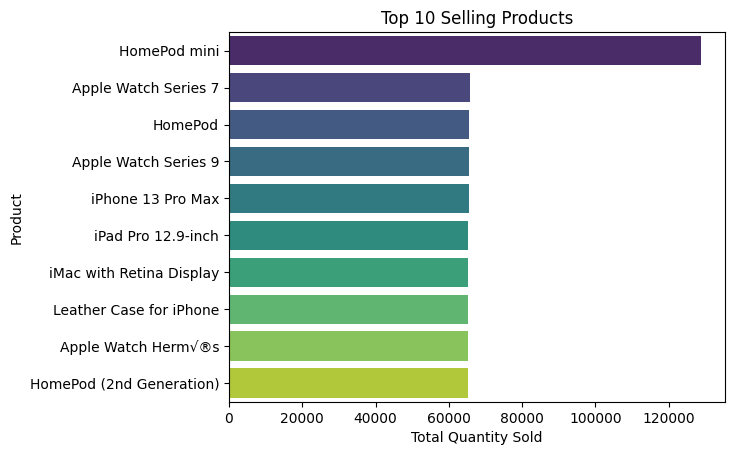

In [9]:
top_products = sales_products_df.groupby('Product_Name')['quantity'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title("Top 10 Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.show()

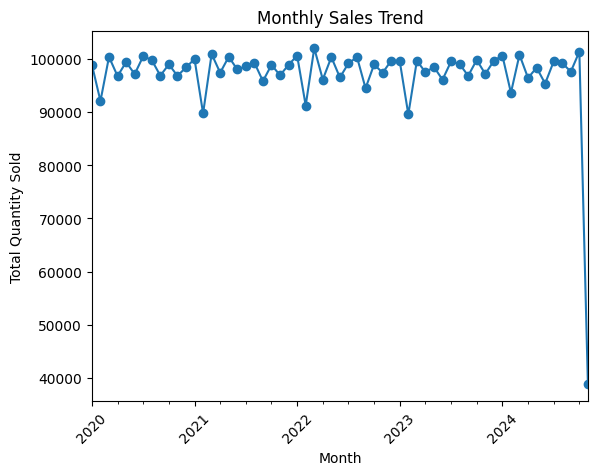

In [10]:
sales_full_df['sale_date'] = pd.to_datetime(sales_full_df['sale_date'])
sales_trend = sales_full_df.groupby(sales_full_df['sale_date'].dt.to_period('M'))['quantity'].sum()
plt.figure()
sales_trend.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()


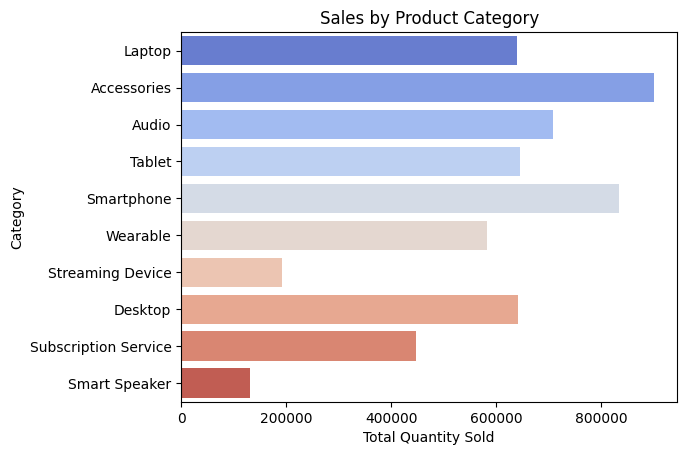

In [11]:
category_sales = sales_full_df.groupby('Category_ID')['quantity'].sum().reset_index()
category_sales = category_sales.merge(category, left_on='Category_ID', right_on='category_id')
plt.figure()
sns.barplot(x='quantity', y='category_name', data=category_sales, palette='coolwarm')
plt.title("Sales by Product Category")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")
plt.show()

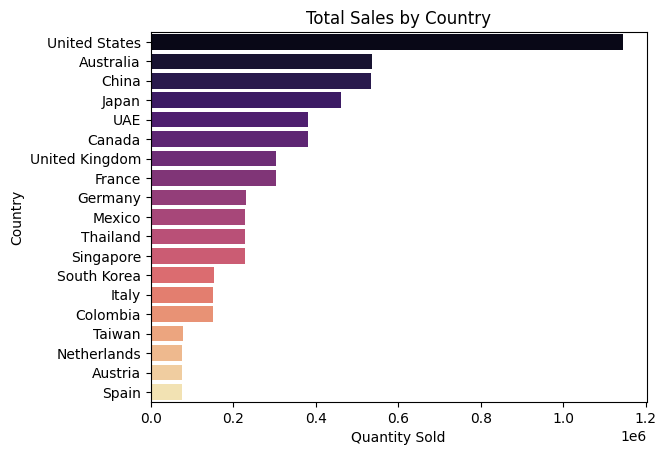

In [12]:
country_sales = sales_full_df.groupby('Country')['quantity'].sum().sort_values(ascending=False)
plt.figure()
sns.barplot(x=country_sales.values, y=country_sales.index, palette='magma')
plt.title("Total Sales by Country")
plt.xlabel("Quantity Sold")
plt.ylabel("Country")
plt.show()

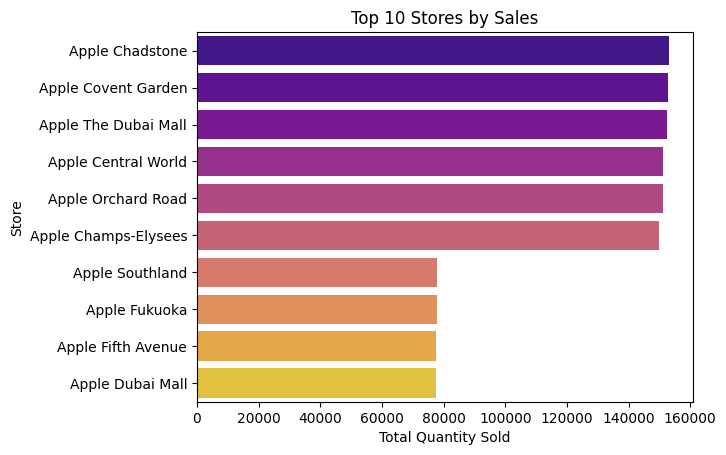

In [13]:
top_stores = sales_full_df.groupby('Store_Name')['quantity'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=top_stores.values, y=top_stores.index, palette='plasma')
plt.title("Top 10 Stores by Sales")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Store")
plt.show()

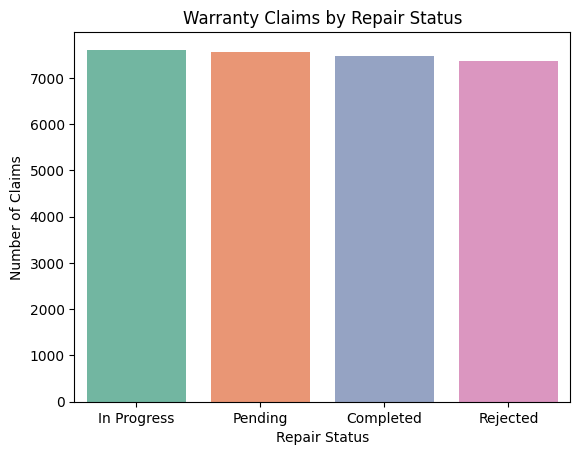

In [14]:
repair_status_count = warranty['repair_status'].value_counts()
plt.figure()
sns.barplot(x=repair_status_count.index, y=repair_status_count.values, palette='Set2')
plt.title("Warranty Claims by Repair Status")
plt.xlabel("Repair Status")
plt.ylabel("Number of Claims")
plt.show()

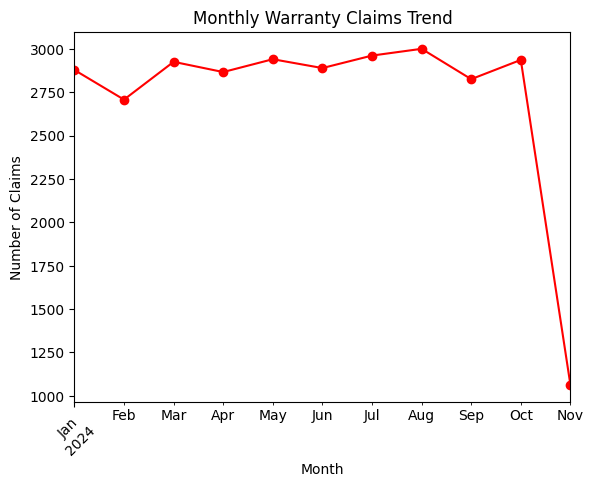

In [15]:
warranty_full_df['claim_date'] = pd.to_datetime(warranty_full_df['claim_date'])
claims_trend = warranty_full_df.groupby(warranty_full_df['claim_date'].dt.to_period('M'))['claim_id'].count()
plt.figure()
claims_trend.plot(marker='o', color='red')
plt.title("Monthly Warranty Claims Trend")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.show()

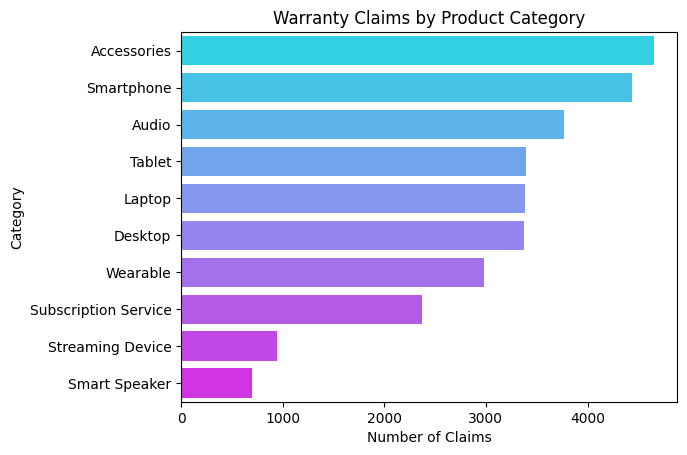

In [16]:
claims_by_category = warranty_full_df.groupby('category_name')['claim_id'].count().sort_values(ascending=False)
plt.figure()
sns.barplot(x=claims_by_category.values, y=claims_by_category.index, palette='cool')
plt.title("Warranty Claims by Product Category")
plt.xlabel("Number of Claims")
plt.ylabel("Category")
plt.show()

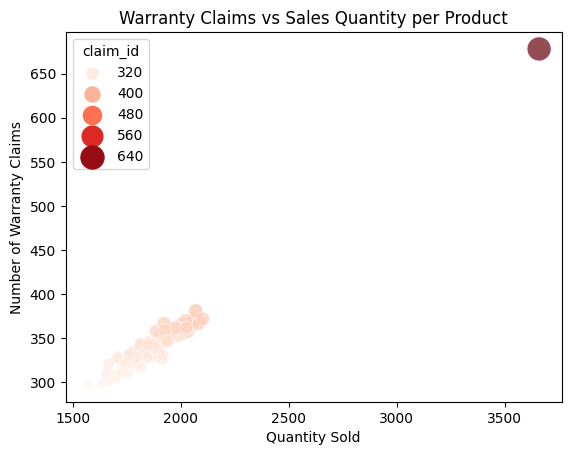

In [17]:
claims_vs_sales = warranty_full_df.groupby('Product_Name').agg({'claim_id':'count','quantity':'sum'}).reset_index()
plt.figure()
sns.scatterplot(x='quantity', y='claim_id', data=claims_vs_sales, hue='claim_id', palette='Reds', size='claim_id', sizes=(50,300), alpha=0.7)
plt.title("Warranty Claims vs Sales Quantity per Product")
plt.xlabel("Quantity Sold")
plt.ylabel("Number of Warranty Claims")
plt.show()

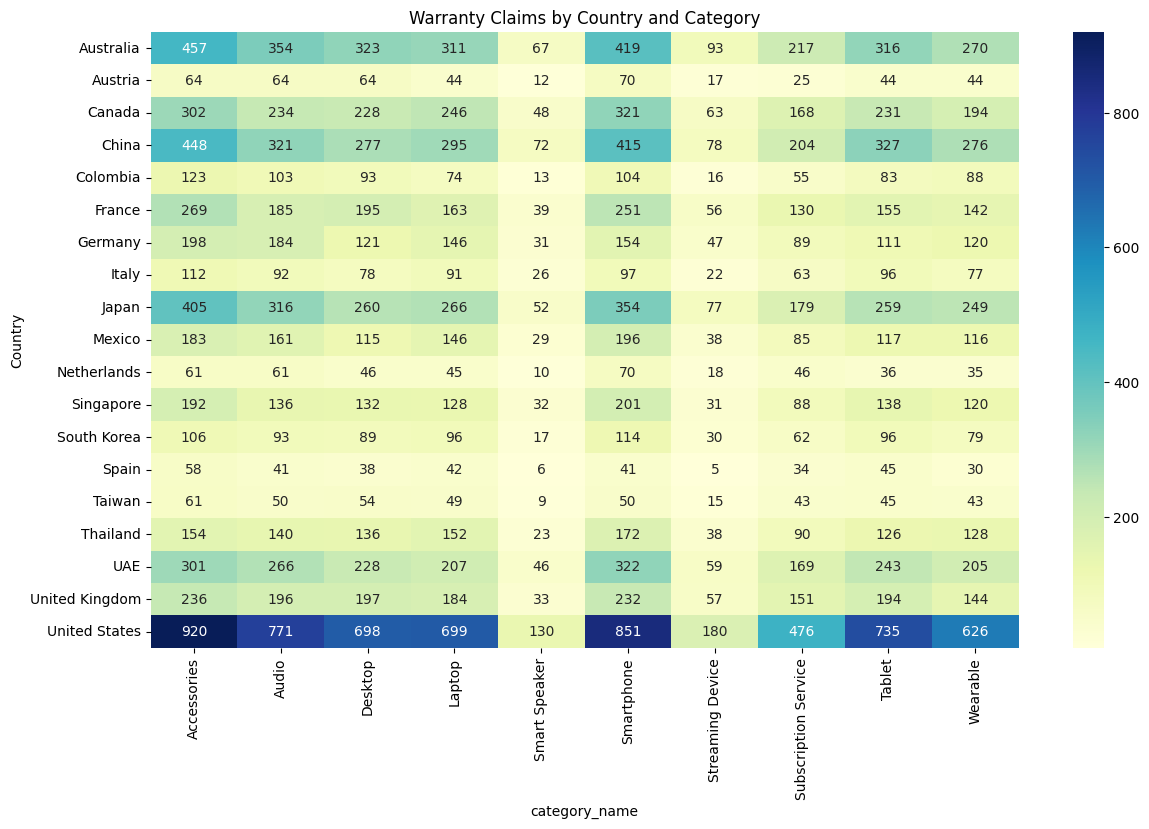

In [18]:
claims_heatmap = warranty_full_df.pivot_table(index='Country', columns='category_name', values='claim_id', aggfunc='count', fill_value=0)
plt.figure(figsize=(14,8))
sns.heatmap(claims_heatmap, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Warranty Claims by Country and Category")
plt.show()

## ML Algorithms

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [20]:
sales_products_df = sales.merge(products, left_on='product_id', right_on='Product_ID', how='left')
sales_full_df = sales_products_df.merge(stores, left_on='store_id', right_on='Store_ID', how='left')
full_df = sales_full_df.merge(warranty[['sale_id','claim_id']], on='sale_id', how='left')

# Binary target: claim exists or not
full_df['claim_flag'] = full_df['claim_id'].apply(lambda x: 0 if pd.isna(x) else 1)

# Features
features = ['quantity', 'Price', 'Category_ID', 'Store_Name', 'City', 'Country', 'Product_Name']
X = full_df[features]
y = full_df['claim_flag']

In [21]:
cat_cols = ['Category_ID', 'Store_Name', 'City', 'Country', 'Product_Name']

In [22]:
X_tree = X.copy()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_tree[col] = le.fit_transform(X_tree[col].astype(str))
    le_dict[col] = le

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_linear = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train-test split
X_train_tree, X_test_tree, y_train, y_test = train_test_split(X_tree, y, test_size=0.2, random_state=42)
X_train_lin, X_test_lin, _, _ = train_test_split(X_linear, y, test_size=0.2, random_state=42)

In [25]:
tree_models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

linear_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB()
}

In [26]:
accuracy_dict = {}

In [27]:
for name, model in tree_models.items():
    model.fit(X_train_tree, y_train)
    y_pred = model.predict(X_test_tree)
    accuracy_dict[name] = accuracy_score(y_test, y_pred) * 100
for name, model in linear_models.items():
    model.fit(X_train_lin, y_train)
    y_pred = model.predict(X_test_lin)
    accuracy_dict[name] = accuracy_score(y_test, y_pred) * 100

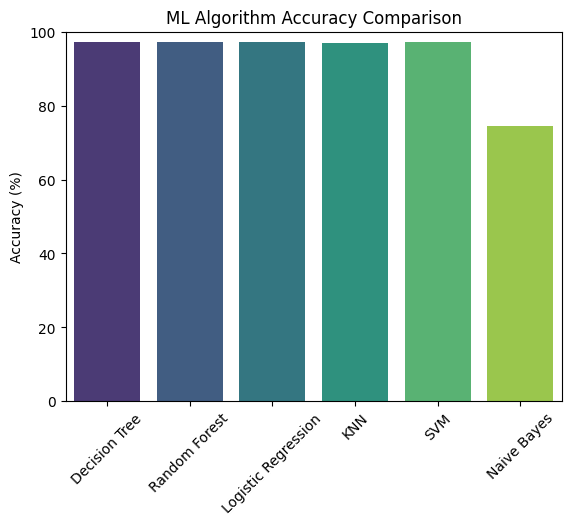

In [28]:
plt.figure()
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='viridis')
plt.ylabel("Accuracy (%)")
plt.title("ML Algorithm Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0,100)
plt.show()

## Thank you..pls upvote!!!